In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential

In [2]:
dataset_path = r"C:\Users\shai\Desktop\ml_projects\GIT\DEEP_LEARNING\DATASETS\xray_dataset_covid19"

In [4]:
# Loading Dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path + r"\train",
    labels="inferred",
    label_mode="binary",
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path + r"\test",
    labels="inferred",
    label_mode="binary",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 148 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [5]:
print(train_dataset.class_names)
for images, labels in train_dataset.take(1):
    print("Image Shape :", images.shape)
    print("Label Shape :", labels.shape)

['NORMAL', 'PNEUMONIA']
Image Shape : (32, 224, 224, 3)
Label Shape : (32, 1)


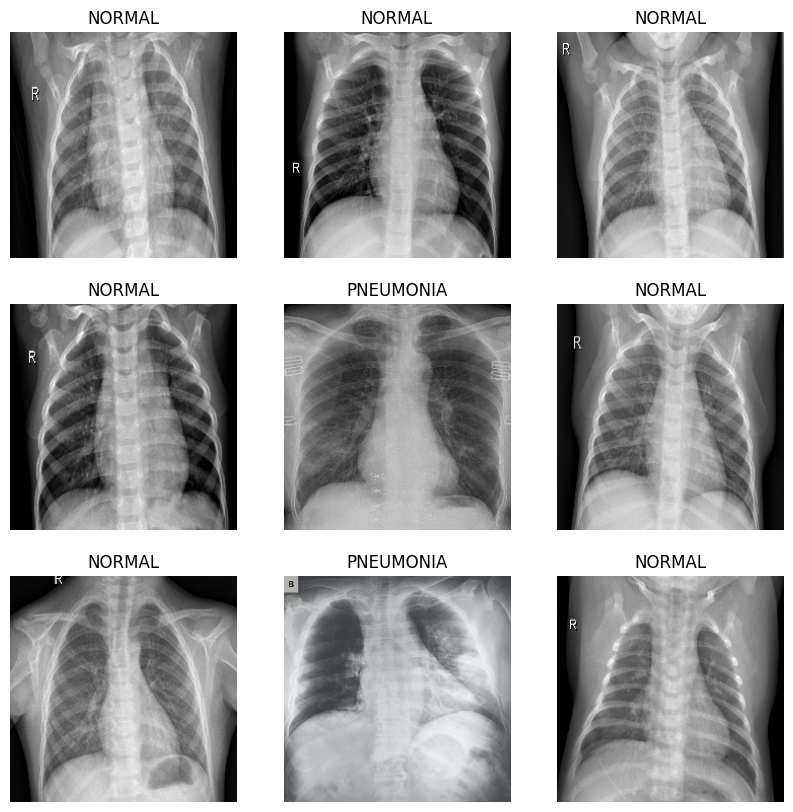

In [6]:
class_names = train_dataset.class_names

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.show()

In [7]:
print(train_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


In [8]:
# Normalizing Images

normalization_layer = tf.keras.layers.Rescaling(1.0/255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [13]:
model = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )

])

c:\Users\shai\Desktop\ml_projects\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

In [16]:
history = model.fit(

    train_dataset,

    validation_data=test_dataset,

    epochs=10

)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 529ms/step - accuracy: 0.6419 - loss: 2.3839 - val_accuracy: 0.5250 - val_loss: 0.6545
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 503ms/step - accuracy: 0.7365 - loss: 0.5331 - val_accuracy: 0.7000 - val_loss: 0.4075
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 0.8243 - loss: 0.3477 - val_accuracy: 0.9750 - val_loss: 0.1724
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 0.9392 - loss: 0.1961 - val_accuracy: 1.0000 - val_loss: 0.0291
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.9189 - loss: 0.1703 - val_accuracy: 1.0000 - val_loss: 0.0152
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9797 - loss: 0.0807 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 0.9730 - loss: 0.0781 - val_accuracy: 1.0000 - val_loss: 0.0193
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.9932 - loss: 0.0446 - val_accuracy: 1.0000 - val_loss:

In [17]:
loss, accuracy = model.evaluate(test_dataset)

print("Loss :", loss)

print("Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0080 
Loss : 0.007986058481037617
Accuracy : 1.0


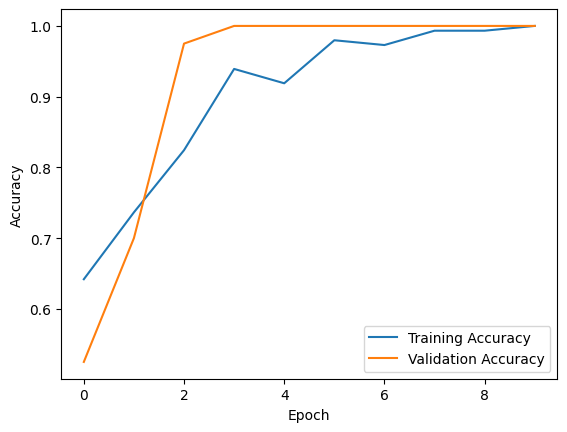

In [18]:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

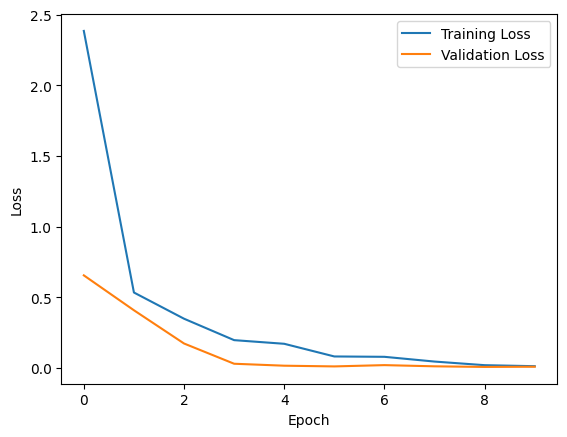

In [19]:
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

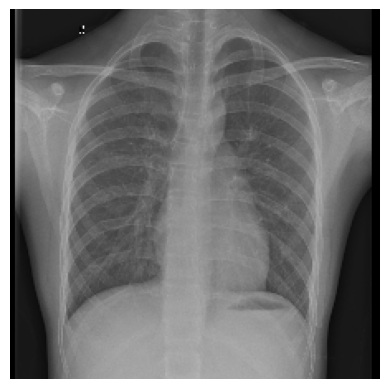

In [21]:
image = tf.keras.preprocessing.image.load_img(
    dataset_path + r"\single prediction\normal_or_pneumonia1.jpeg",
    target_size=(224,224)
)

plt.imshow(image)

plt.axis("off")

plt.show()

In [22]:
image = tf.keras.preprocessing.image.img_to_array(image)

image = image / 255.0

image = np.expand_dims(image,axis=0)

print(image.shape)

(1, 224, 224, 3)


In [23]:
prediction = model.predict(image)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[0.03072822]]


In [24]:
if prediction[0][0] > 0.5:
    print("Prediction : Pneumonia")
else:
    print("Prediction : Normal")

Prediction : Normal


In [25]:
model.save("pneumonia_model.keras")